# Session 6 

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
np.random.seed(4)

## Task 1 — Jointplot (scatter): Flipkart Rating vs Price

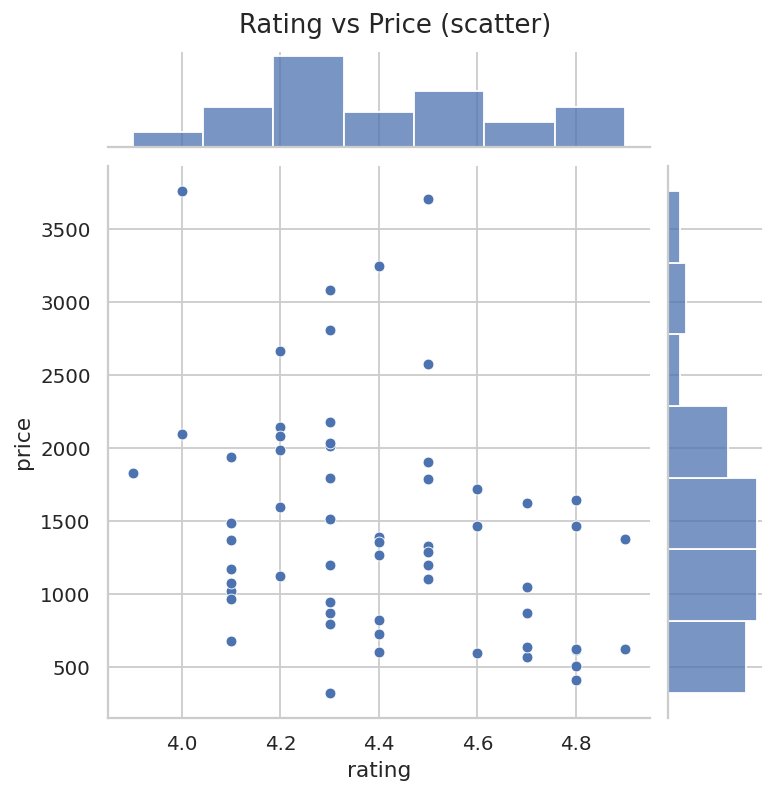

In [1]:
n = 60
price = np.random.gamma(3, 500, n).round()
rating = (4.6 - price / 8000 + np.random.normal(0, 0.25, n)).clip(1, 5).round(1)
flipkart_df = pd.DataFrame({'price': price, 'rating': rating})

g = sns.jointplot(data=flipkart_df, x='rating', y='price', kind='scatter')
g.figure.suptitle('Rating vs Price (scatter)', y=1.02)
plt.show()

## Task 2 — Jointplot (hex): Swiggy Delivery Time vs Order Value

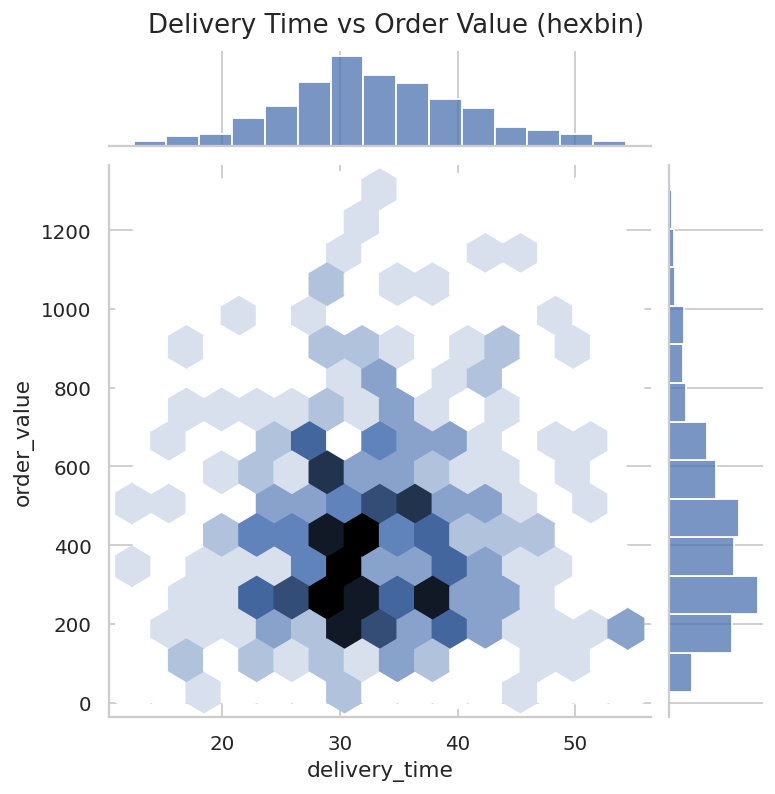

In [1]:
n2 = 300
delivery_time = np.random.normal(32, 8, n2).clip(10, None)
order_value = np.random.gamma(3, 150, n2)
swiggy_df = pd.DataFrame({'delivery_time': delivery_time, 'order_value': order_value})

g = sns.jointplot(data=swiggy_df, x='delivery_time', y='order_value', kind='hex')
g.figure.suptitle('Delivery Time vs Order Value (hexbin)', y=1.02)
plt.show()

## Task 3 — Jointplot (kde): Instagram Likes vs Comments

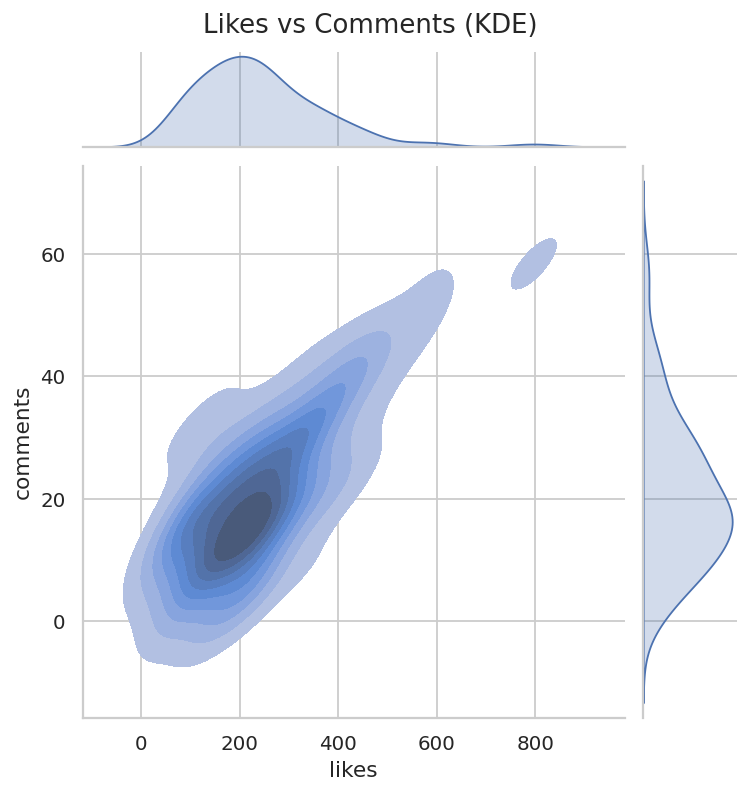

In [1]:
n3 = 150
likes = np.random.gamma(4, 60, n3)
comments = (likes * 0.08 + np.random.normal(0, 8, n3)).clip(0, None)
insta_df = pd.DataFrame({'likes': likes, 'comments': comments})

g = sns.jointplot(data=insta_df, x='likes', y='comments', kind='kde', fill=True)
g.figure.suptitle('Likes vs Comments (KDE)', y=1.02)
plt.show()

## Task 4 — Comparing scatter, hex, and KDE: Zomato Rating vs Number of Reviews

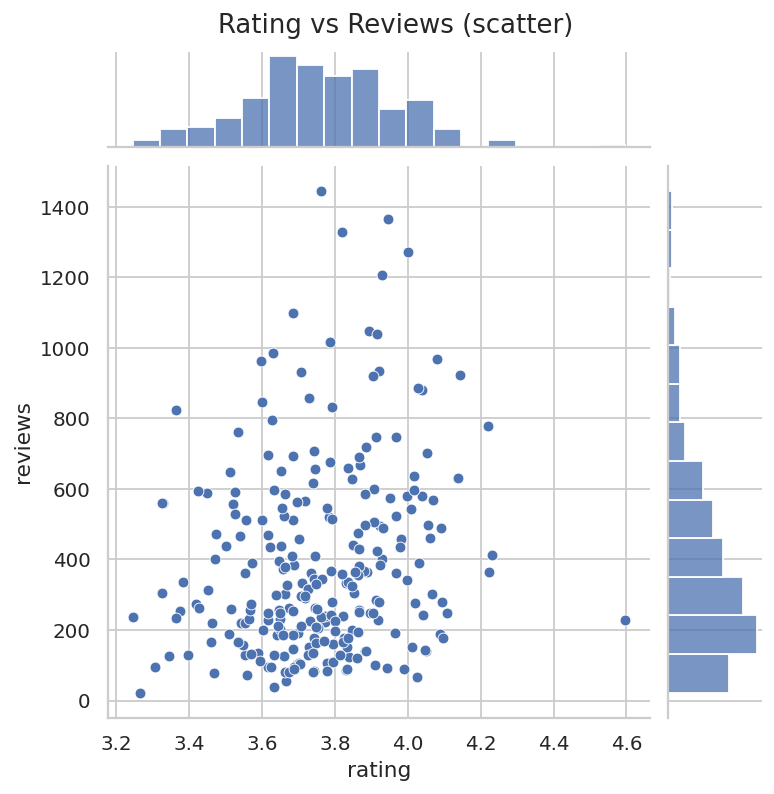

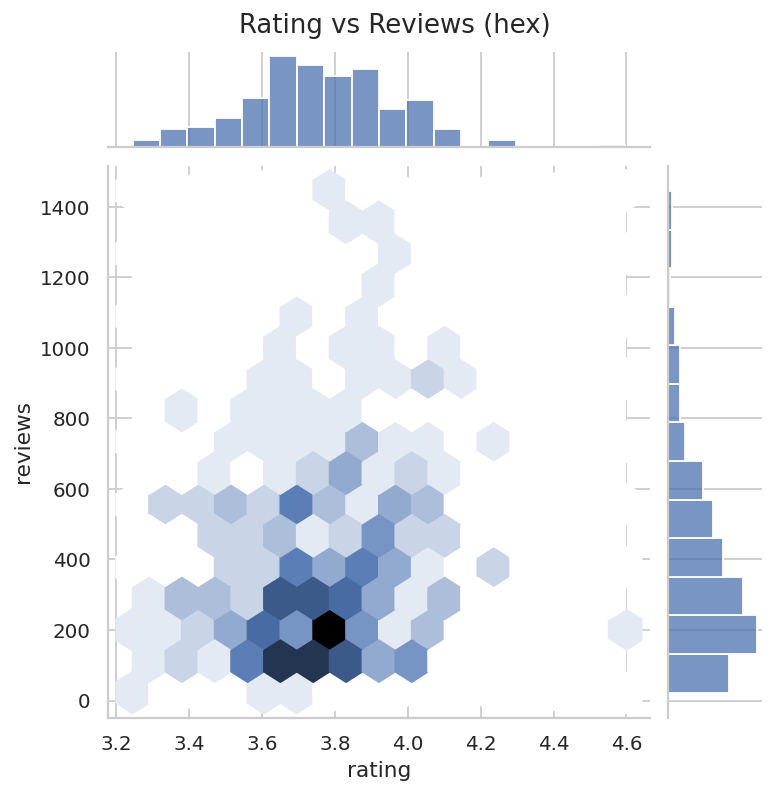

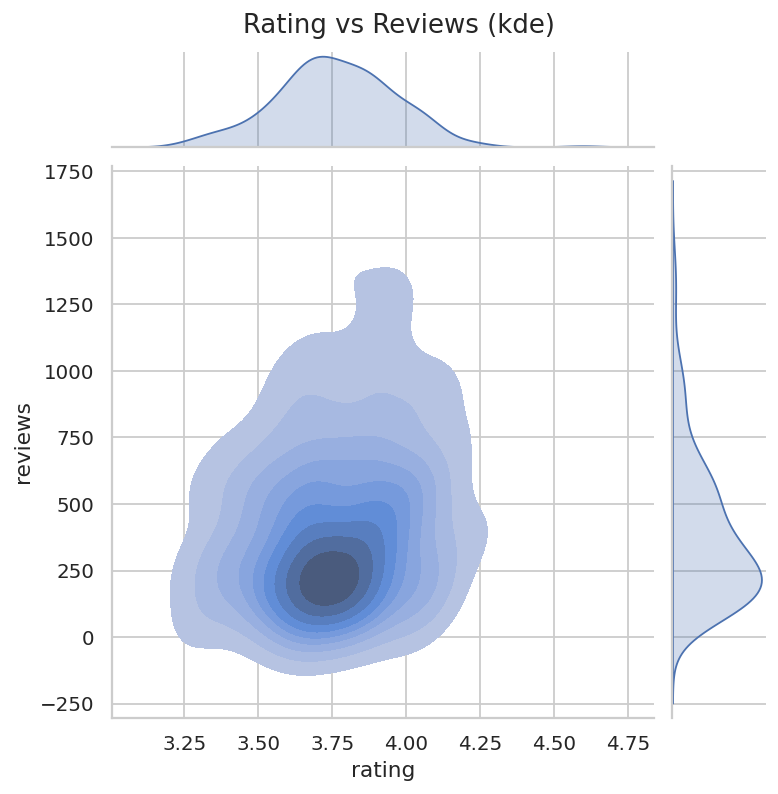

In [1]:
n4 = 250
reviews = np.random.gamma(2, 200, n4)
zomato_rating = (3.3 + np.log1p(reviews) / 12 + np.random.normal(0, 0.2, n4)).clip(1, 5)
zomato_df = pd.DataFrame({'rating': zomato_rating, 'reviews': reviews})

for kind in ['scatter', 'hex', 'kde']:
    kwargs = {'fill': True} if kind == 'kde' else {}
    g = sns.jointplot(data=zomato_df, x='rating', y='reviews', kind=kind, **kwargs)
    g.figure.suptitle(f'Rating vs Reviews ({kind})', y=1.02)
    plt.show()

**Comparison:** the **scatter** plot is best for spotting individual outlier restaurants (e.g., one with an unusually huge review count) since every point is visible on its own. The **hexbin** plot is the most useful here overall — with 250 overlapping points, scatter gets cluttered in the dense low-review region, and hexbin's color-coded density cleanly shows where most restaurants actually sit. The **KDE** plot gives the smoothest, most presentation-friendly read of the general trend (more reviews → slightly higher rating) but can visually imply structure or smoothness that isn't really in the raw, noisier data.